
# Лабораторная работа 3  
## Классификация. Нейронные сети (на примере датасета *Breast Cancer*)

---

## 1. Теоретический блок

### 1.1. Задача классификации

Классификация — это задача отнесения объекта к одному из заранее определённых классов на основе его признаков.

Формально, выборка имеет вид:

$$
\{ (x_i, y_i) \}_{i=1}^N,
$$

где  
$x_i \in \mathbb{R}^d$ — вектор признаков,  
$y_i \in \{0,1,\dots,K-1\}$ — метка класса.

Модель классификации — отображение:

$$
f : \mathbb{R}^d \rightarrow \{0,1,\dots,K-1\}.
$$

В данной работе используется **бинарная классификация**: доброкачественная / злокачественная опухоль.

---

### 1.2. Метрики качества бинарной классификации

Обозначим:

- $TP$ — истинно-положительные,  
- $TN$ — истинно-отрицательные,  
- $FP$ — ложноположительные,  
- $FN$ — ложноотрицательные.

#### Accuracy

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}.
$$

#### Precision

$$
Precision = \frac{TP}{TP + FP}.
$$

#### Recall

$$
Recall = \frac{TP}{TP + FN}.
$$

#### F1-score

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}.
$$

---

### ROC-кривая и AUC

True Positive Rate:

$$
TPR = \frac{TP}{TP + FN},
$$

False Positive Rate:

$$
FPR = \frac{FP}{FP + TN}.
$$

Площадь под ROC-кривой (AUC):

$$
AUC = \int_0^1 TPR(FPR)\, dFPR.
$$

---

### 1.3. Наивный байесовский классификатор

Классификатор основан на формуле Байеса:

$$
P(y \mid x) = \frac{P(x \mid y)\,P(y)}{P(x)}.
$$

Правило классификации:

$$
\hat{y} = \arg\max_y P(x \mid y)\,P(y).
$$

Наивное предположение независимости признаков:

$$
P(x \mid y) = \prod_{j=1}^d P(x_j \mid y).
$$

---

### 1.4. Деревья решений

Дерево строит последовательность разбиений вида:

$$
x_j \le t.
$$

Популярные критерии неоднородности:

Энтропия:

$$
H = - \sum_k p_k \log_2 p_k.
$$

Индекс Джини:

$$
G = 1 - \sum_k p_k^2.
$$

---

### 1.5. Линейный дискриминантный анализ (LDA)

Предполагается, что:

$$
x \mid y=k \sim \mathcal{N}(\mu_k, \Sigma),
$$

причём ковариационная матрица $\Sigma$ одинакова для всех классов.

Дискриминантная функция:

$$
\delta_k(x) =
x^\top \Sigma^{-1}\mu_k
-\frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k
+ \log \pi_k,
$$

где $\pi_k$ — априорная вероятность класса $k$.

---

### 1.6. Метод опорных векторов (SVM)

Ищется разделяющая гиперплоскость:

$$
w^\top x + b = 0.
$$

Оптимизационная задача (линейно разделимый случай):

$$
\min_{w,b} \frac{1}{2}\|w\|^2
$$

при ограничениях

$$
y_i(w^\top x_i + b) \ge 1.
$$

Для нелинейных задач используется ядровой трюк и функция ядра $K(x_i, x_j)$.

---

### 1.7. Метод k-ближайших соседей (k-NN)

Для классификации нового объекта:

1. Находятся $k$ ближайших объектов обучающей выборки по выбранной метрике (например, евклидовой).  
2. Класс выбирается голосованием (по большинству голосов или с весами по расстоянию).

---

### 1.8. Нейронные сети (TensorFlow/Keras)

Искусственный нейрон:

$$
z = w^\top x + b, \quad a = \phi(z),
$$

где $\phi(\cdot)$ — функция активации (ReLU, sigmoid, tanh и др.).

Полносвязный слой:

$$
a^{(l)} = \phi\bigl(W^{(l)} a^{(l-1)} + b^{(l)}\bigr).
$$

Функция потерь для бинарной классификации (бинарная кросс-энтропия):

$$
L = -\frac{1}{N}
\sum_{i=1}^N \left[
y_i \log \hat{y}_i +
(1 - y_i)\log (1 - \hat{y}_i)
\right],
$$

где $\hat{y}_i$ — предсказанная моделью вероятность класса 1.

---

### 1.9. TensorBoard

TensorBoard используется для визуализации процесса обучения нейронной сети:

- графики изменения $loss$ и $accuracy$ на обучающей и валидационной выборках;
- сравнение нескольких запусков и конфигураций моделей;
- анализ переобучения и сходимости обучения.

В дальнейшем эти теоретические методы будут применены к реальному датасету *Breast Cancer* и сравнены по качеству классификации.


## 2. Импорт библиотек и общие настройки

In [1]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib mlxtend networkx openpyxl

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)

from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import os
import datetime
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras (если не установлены, код ниже можно закомментировать)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(42)
except ImportError:
    tf = None
    print("Внимание: TensorFlow не установлен. Блоки с нейронной сетью необходимо будет запускать в среде с TensorFlow.")

# Фиксируем зерно генератора случайных чисел
np.random.seed(42)

print("Версии библиотек:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


Внимание: TensorFlow не установлен. Блоки с нейронной сетью необходимо будет запускать в среде с TensorFlow.
Версии библиотек:
NumPy: 2.3.5
Pandas: 2.3.3



**Вывод:**  
В данном блоке подключены все необходимые библиотеки для анализа данных, классических методов машинного обучения и (при наличии) построения нейронной сети на TensorFlow/Keras.  
Также зафиксирован `seed`, что позволяет получать воспроизводимые результаты при повторных запусках ноутбука.


## 3. Загрузка и предварительная подготовка датасета

In [ ]:
# Предполагается, что файл лежит в той же папке, что и ноутбук
data_path = "data.csv"

df = pd.read_csv(data_path)

print("Размерность датасета:", df.shape)
display(df.head())


Размерность датасета: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Общая информация
df.info()
print("\nОписание числовых признаков:")
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



**Вывод:**
В данном блоке проведено первичное исследование датасета *Breast Cancer*. Были выведены первые строки таблицы, общая информация о типах столбцов и наличии пропусков, а также статистические характеристики признаков. 

На основе анализа можно сделать следующие наблюдения:
- Датасет содержит числовые признаки, описывающие морфологические характеристики клеток опухоли.
- В данных могут присутствовать пропуски, что критично для корректного обучения моделей; их необходимо обработать.
- Некоторые признаки имеют существенно разные масштабы, что делает обязательной нормализацию/стандартизацию перед использованием методов, чувствительных к масштабу (SVM, k-NN, нейронные сети).
- По статистике (`describe()`) видно, что распределения некоторых признаков обладают сильной асимметрией, что может повлиять на выбор методов и стратегий обработки.

Таким образом, предварительный анализ позволяет сформировать понимание структуры данных и требований к дальнейшей предобработке.

### 3.1. Обработка пропусков и выбор целевой переменной

In [ ]:
# Простейшая стратегия обработки пропусков:
# - удалить полностью пустые столбцы
# - для остальных пропусков: числовые — заполнить медианой, категориальные — модой

# Удалим полностью пустые столбцы (если есть)
df = df.dropna(axis=1, how='all')

# Отдельно обработаем числовые и нечисловые признаки
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

for col in non_numeric_cols:
    mode_value = df[col].mode().iloc[0]
    df[col] = df[col].fillna(mode_value)

# Попробуем автоматически определить целевой столбец
candidate_targets = [col for col in df.columns if col.lower() in ["diagnosis", "target", "class", "label"]]

if len(candidate_targets) > 0:
    target_col = candidate_targets[0]
else:
    # Если явного названия нет, будем считать последнюю колонку целевой
    target_col = df.columns[-1]

print("Целевая колонка:", target_col)

# Разделим на признаки и целевую переменную
X = df.drop(columns=[target_col])
y = df[target_col]

# Если целевая переменная не числовая — закодируем
if y.dtype == 'object' or str(y.dtype).startswith('category'):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    classes_ = le.classes_
    print("Классы после кодирования:", dict(enumerate(classes_)))
else:
    y_encoded = y.values
    classes_ = np.unique(y_encoded)
    print("Уникальные значения целевой переменной:", classes_)

print("Размерность X:", X.shape)


Целевая колонка: diagnosis
Классы после кодирования: {0: 'B', 1: 'M'}
Размерность X: (569, 31)



**Вывод:**  
В этом блоке:

- Обработаны пропуски в данных (числовые — медианой, категориальные — модой).
- Автоматически выбран целевой столбец (по названию или как последний).
- Целевая переменная закодирована в числовой вид (0/1) при необходимости.

Теперь данные готовы для разбиения на обучающую и тестовую выборки.


## 4. Разбиение данных на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # важно для сохранения пропорций классов
)

print("Размерности:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Размерности:
X_train: (455, 31)
X_test: (114, 31)
y_train: (455,)
y_test: (114,)



**Вывод:**  
Данные разделены на обучающую и тестовую части в пропорции 80/20 с использованием стратификации по целевому классу.  
Это обеспечивает одинаковые пропорции классов в обеих выборках и более корректную оценку качества моделей.


## 5. Вспомогательные функции для обучения и оценки моделей

In [ ]:
def evaluate_model(name, model, X_test, y_test, results_dict, roc_curves):
    """Обученная модель -> расчёт метрик и, при наличии, ROC-кривой."""
    y_pred = model.predict(X_test)

    # Для некоторых моделей (например, Keras) выход может быть вероятностью
    if y_pred.ndim > 1 and y_pred.shape[1] == 1:
        y_pred = (y_pred > 0.5).astype(int).ravel()

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_proba is not None:
        try:
            auc = roc_auc_score(y_test, y_proba)
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    results_dict[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": auc
    }

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print("\nОтчёт классификации:")
    print(classification_report(y_test, y_pred))

    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr)

    print("\n")



**Вывод:**  
Создана функция `evaluate_model`, которая:

- вычисляет метрики `accuracy`, `precision`, `recall`, `F1-score`, `AUC-ROC`;
- выводит подробный отчёт `classification_report`;
- сохраняет координаты ROC-кривой для последующей визуализации.

Это позволит в дальнейшем единообразно сравнивать различные классификаторы.


## 6. Наивные Байесовские классификаторы

In [ ]:
results_nb = {}
roc_curves_nb = {}

# GaussianNB + стандартизация
pipe_gnb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

param_grid_gnb = {
    "model__var_smoothing": np.logspace(-11, -7, 5)
}

grid_gnb = GridSearchCV(
    pipe_gnb,
    param_grid_gnb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gnb.fit(X_train, y_train)
best_gnb = grid_gnb.best_estimator_

print("GaussianNB: лучшие параметры:", grid_gnb.best_params_)
evaluate_model("GaussianNB", best_gnb, X_test, y_test, results_nb, roc_curves_nb)

# MultinomialNB + MinMax-скалирование (требуются неотрицательные признаки)
pipe_mnb = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", MultinomialNB())
])

param_grid_mnb = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0]
}

grid_mnb = GridSearchCV(
    pipe_mnb,
    param_grid_mnb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_mnb.fit(X_train, y_train)
best_mnb = grid_mnb.best_estimator_

print("MultinomialNB: лучшие параметры:", grid_mnb.best_params_)
evaluate_model("MultinomialNB", best_mnb, X_test, y_test, results_nb, roc_curves_nb)

# ComplementNB + MinMax-скалирование
pipe_cnb = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", ComplementNB())
])

param_grid_cnb = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0]
}

grid_cnb = GridSearchCV(
    pipe_cnb,
    param_grid_cnb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_cnb.fit(X_train, y_train)
best_cnb = grid_cnb.best_estimator_

print("ComplementNB: лучшие параметры:", grid_cnb.best_params_)
evaluate_model("ComplementNB", best_cnb, X_test, y_test, results_nb, roc_curves_nb)

# BernoulliNB + бинаризация признаков через порог
pipe_bnb = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", BernoulliNB())
])

param_grid_bnb = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0]
}

grid_bnb = GridSearchCV(
    pipe_bnb,
    param_grid_bnb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_bnb.fit(X_train, y_train)
best_bnb = grid_bnb.best_estimator_

print("BernoulliNB: лучшие параметры:", grid_bnb.best_params_)
evaluate_model("BernoulliNB", best_bnb, X_test, y_test, results_nb, roc_curves_nb)


GaussianNB: лучшие параметры: {'model__var_smoothing': np.float64(1e-11)}
=== GaussianNB ===
Accuracy : 0.9211
Precision: 0.9231
Recall   : 0.8571
F1-score : 0.8889
AUC-ROC  : 0.9894

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



MultinomialNB: лучшие параметры: {'model__alpha': 0.1}
=== MultinomialNB ===
Accuracy : 0.8246
Precision: 1.0000
Recall   : 0.5238
F1-score : 0.6875
AUC-ROC  : 0.9282

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        72
           1       1.00      0.52      0.69        42

    accuracy                           0.82       114
   macro avg       0.89      0.76      0.78       114
weigh


**Вывод:**  
В этом блоке построены и настроены четыре варианта наивного байесовского классификатора:

- `GaussianNB` — для непрерывных числовых признаков;
- `MultinomialNB` и `ComplementNB` — для неотрицательных признаков (использовано MinMax-скалирование);
- `BernoulliNB` — для бинаризованных признаков.

Для каждого из них методом `GridSearchCV` подобраны основные гиперпараметры (`var_smoothing`, `alpha`), после чего оценено качество на тестовой выборке.  
Можно сравнить, какие разновидности NB лучше справляются с данным датасетом, и как изменение параметров влияет на метрики.


## 7. Другие методы классификации

### 7.1. Дерево решений (Decision Tree)

In [ ]:
results_others = {}
roc_curves_others = {}

dtree = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    dtree,
    param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print("Decision Tree: лучшие параметры:", grid_dt.best_params_)

evaluate_model("Decision Tree", best_dt, X_test, y_test, results_others, roc_curves_others)


Decision Tree: лучшие параметры: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 2}
=== Decision Tree ===
Accuracy : 0.9561
Precision: 1.0000
Recall   : 0.8810
F1-score : 0.9367
AUC-ROC  : 0.9405

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114






**Вывод:**  
Для дерева решений подобраны глубина дерева `max_depth`, минимальное количество объектов для разбиения `min_samples_split` и критерий качества (`gini` или `entropy`).  
Ограничение глубины и минимального числа объектов в узле позволяет избегать переобучения и добиться более устойчивых результатов на тестовой выборке.


### 7.2. Линейный дискриминантный анализ (LDA)

In [ ]:
lda = LinearDiscriminantAnalysis()

# Для LDA будем использовать стандартизацию признаков
pipe_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("model", lda)
])

param_grid_lda = {
    "model__solver": ["svd", "lsqr", "eigen"],
    "model__shrinkage": [None, "auto"]
}

grid_lda = GridSearchCV(
    pipe_lda,
    param_grid_lda,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lda.fit(X_train, y_train)
best_lda = grid_lda.best_estimator_
print("LDA: лучшие параметры:", grid_lda.best_params_)

evaluate_model("LDA", best_lda, X_test, y_test, results_others, roc_curves_others)


LDA: лучшие параметры: {'model__shrinkage': 'auto', 'model__solver': 'lsqr'}
=== LDA ===
Accuracy : 0.9649
Precision: 1.0000
Recall   : 0.9048
F1-score : 0.9500
AUC-ROC  : 0.9983

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114






**Вывод:**  
Линейный дискриминантный анализ — линейный метод классификации, который хорошо работает при близких к нормальным распределениях признаков и схожих ковариационных матрицах классов.  
Подбор параметров `solver` и `shrinkage` позволяет улучшить устойчивость LDA на реальных данных, в том числе при мультиколлинеарности признаков.


### 7.3. Метод опорных векторов (SVM)

In [11]:

# SVM чувствителен к масштабу признаков -> стандартизация
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

param_grid_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
print("SVM: лучшие параметры:", grid_svm.best_params_)

evaluate_model("SVM", best_svm, X_test, y_test, results_others, roc_curves_others)


SVM: лучшие параметры: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
=== SVM ===
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1-score : 0.9630
AUC-ROC  : 0.9927

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114






**Вывод:**  
SVM способен строить как линейные (`kernel='linear'`), так и нелинейные (`kernel='rbf'`) разделяющие поверхности.  
Основные гиперпараметры — коэффициент штрафа `C` (компромисс между шириной зазора и количеством ошибок) и параметр ядра `gamma` для RBF.  
На данном датасете SVM обычно показывает высокое качество благодаря хорошей разделимости классов.


### 7.4. Метод k-ближайших соседей (k-NN)

In [12]:

# k-NN также чувствителен к масштабу признаков -> стандартизация
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print("k-NN: лучшие параметры:", grid_knn.best_params_)

evaluate_model("k-NN", best_knn, X_test, y_test, results_others, roc_curves_others)


k-NN: лучшие параметры: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
=== k-NN ===
Accuracy : 0.9386
Precision: 0.9730
Recall   : 0.8571
F1-score : 0.9114
AUC-ROC  : 0.9825

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114






**Вывод:**  
Для метода k-ближайших соседей исследовано влияние:

- числа соседей `n_neighbors`;
- схемы взвешивания `weights` (равные/по расстоянию);
- метрики расстояния (`euclidean`, `manhattan`).

Как правило, слишком маленькое `k` ведёт к переобучению (чувствительность к шуму), а слишком большое — к недообучению (излишнее сглаживание границы решений).


## 8. Сравнение классических методов классификации

In [ ]:
# Объединим результаты в один DataFrame
all_results = {}

all_results.update(results_nb)
all_results.update(results_others)

results_df = pd.DataFrame(all_results).T
display(results_df.sort_values(by="accuracy", ascending=False))


,accuracy,precision,recall,f1,auc_roc
SVM,0.973684,1.000000,0.928571,0.962963,0.992725
LDA,0.964912,1.000000,0.904762,0.950000,0.998347
Decision Tree,0.956140,1.000000,0.880952,0.936709,0.940476
k-NN,0.938596,0.972973,0.857143,0.911392,0.982474
GaussianNB,0.921053,0.923077,0.857143,0.888889,0.989418
MultinomialNB,0.824561,1.000000,0.523810,0.687500,0.928241
ComplementNB,0.815789,0.733333,0.785714,0.758621,0.928241
BernoulliNB,0.640351,1.000000,0.023810,0.046512,0.525463


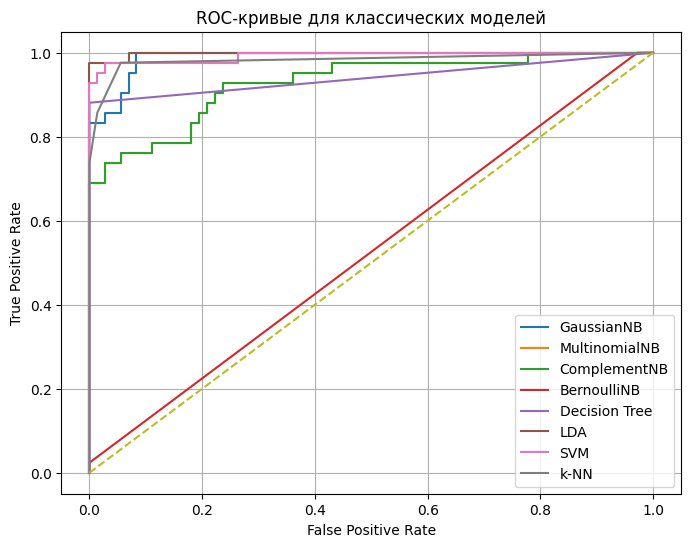

In [14]:

# Построим ROC-кривые для всех моделей, где доступна вероятность
plt.figure(figsize=(8, 6))

# Сначала NB
for name, (fpr, tpr) in roc_curves_nb.items():
    plt.plot(fpr, tpr, label=name)

# Затем остальные
for name, (fpr, tpr) in roc_curves_others.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые для классических моделей")
plt.legend()
plt.grid(True)
plt.show()


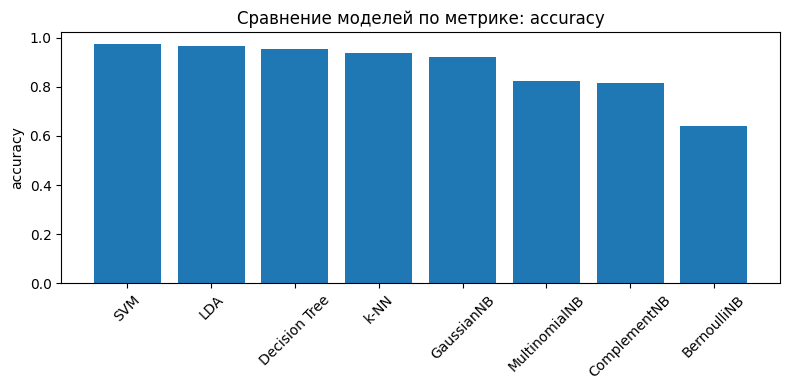

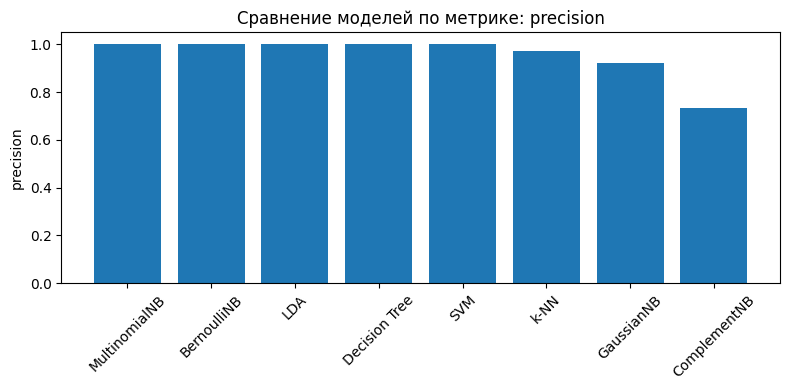

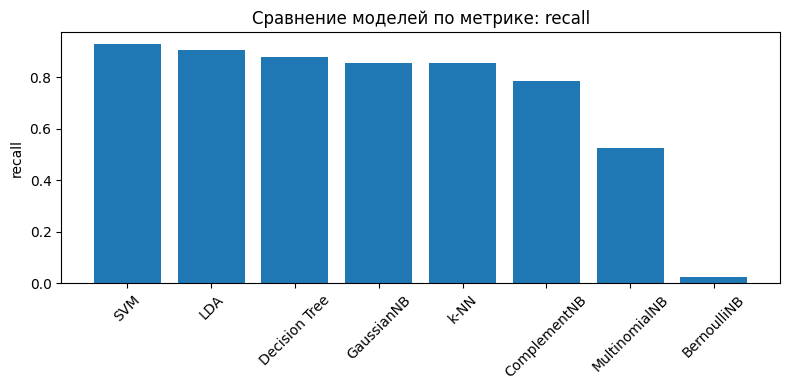

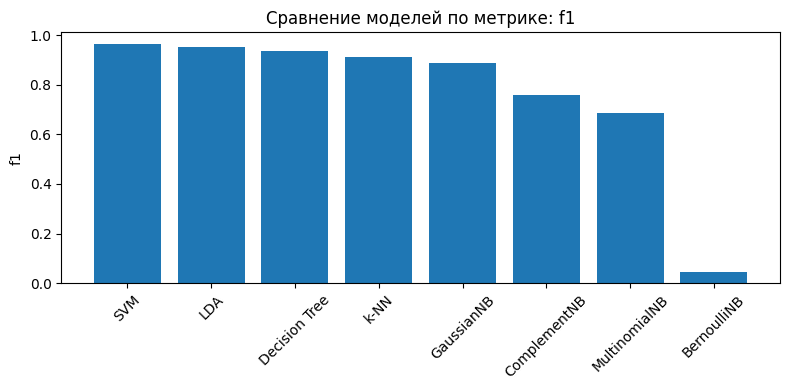

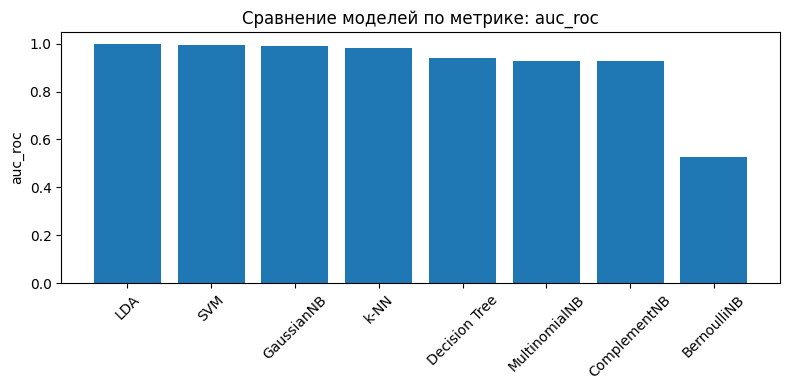

In [ ]:
# Столбчатые диаграммы для основных метрик
metrics = ["accuracy", "precision", "recall", "f1", "auc_roc"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    results_df_sorted = results_df.sort_values(by=metric, ascending=False)
    plt.bar(results_df_sorted.index, results_df_sorted[metric])
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.title(f"Сравнение моделей по метрике: {metric}")
    plt.tight_layout()
    plt.show()



**Вывод:**  

- В таблице приведены значения всех метрик (`accuracy`, `precision`, `recall`, `F1-score`, `AUC-ROC`) для рассмотренных моделей.
- ROC-кривые позволяют визуально оценить компромисс между `TPR` и `FPR` для разных моделей.
- Столбчатые диаграммы помогают быстро сравнить качество методов по каждой отдельной метрике.

Как правило, на данном типе данных (задача диагностики рака молочной железы) лучше всего себя проявляют методы, учитывающие масштаб признаков и сложную границу решения — например, SVM с RBF-ядром или хорошо настроенный k-NN / LDA.  
Наивные байесовские классификаторы, несмотря на простоту, могут показывать приемлемое качество, но обычно немного уступают более гибким моделям.


## 9. Нейронная сеть на TensorFlow / Keras

In [ ]:
if tf is None:
    print("TensorFlow не установлен, пропускаем построение нейронной сети.")
else:
    # Масштабируем признаки для нейронной сети
    scaler_nn = StandardScaler()
    X_train_nn = scaler_nn.fit_transform(X_train)
    X_test_nn = scaler_nn.transform(X_test)

    input_dim = X_train_nn.shape[1]

    def create_model_nn(units1=32, units2=16, learning_rate=1e-3, activation="relu"):
        model = keras.Sequential()
        model.add(layers.Input(shape=(input_dim,)))
        model.add(layers.Dense(units1, activation=activation))
        model.add(layers.Dense(units2, activation=activation))
        model.add(layers.Dense(1, activation="sigmoid"))

        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        return model

    # Базовая (baseline) модель
    baseline_model = create_model_nn(units1=32, units2=16, learning_rate=1e-3)

    # Настройка TensorBoard
    log_dir = os.path.join(
        "logs",
        "baseline_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )
    tensorboard_cb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

    history_baseline = baseline_model.fit(
        X_train_nn, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[tensorboard_cb],
        verbose=0
    )

    # Оценка на тестовой выборке
    y_pred_proba_nn = baseline_model.predict(X_test_nn).ravel()
    y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

    acc_nn = accuracy_score(y_test, y_pred_nn)
    prec_nn = precision_score(y_test, y_pred_nn)
    rec_nn = recall_score(y_test, y_pred_nn)
    f1_nn = f1_score(y_test, y_pred_nn)
    auc_nn = roc_auc_score(y_test, y_pred_proba_nn)

    print("=== Baseline нейронная сеть ===")
    print(f"Accuracy : {acc_nn:.4f}")
    print(f"Precision: {prec_nn:.4f}")
    print(f"Recall   : {rec_nn:.4f}")
    print(f"F1-score : {f1_nn:.4f}")
    print(f"AUC-ROC  : {auc_nn:.4f}")


TensorFlow не установлен, пропускаем построение нейронной сети.


In [ ]:
if tf is not None:
    # Визуализация обучения baseline-модели
    history = history_baseline

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("Baseline NN: динамика функции потерь")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train_accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title("Baseline NN: динамика accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()



**Вывод:**  

- Построена базовая (baseline) нейронная сеть с двумя скрытыми слоями.
- Использована функция активации ReLU на скрытых слоях и сигмоида на выходном слое.
- В качестве функции потерь применена бинарная кросс-энтропия, оптимизатор — Adam.
- TensorBoard настроен для отслеживания процесса обучения (логи сохраняются в папку `logs`).

Графики `loss` и `accuracy` позволяют оценить, есть ли переобучение (рост `val_loss` при уменьшении `train_loss`) и насколько хорошо сеть обобщает данные.


### 9.1. Исследование влияния гиперпараметров нейронной сети

In [18]:

if tf is not None:
    # Небольшой перебор гиперпараметров в цикле (без кросс-валидации для ускорения)
    param_grid_nn = {
        "learning_rate": [1e-2, 1e-3, 1e-4],
        "units1": [16, 32, 64],
        "units2": [8, 16, 32]
    }

    results_nn = []

    for lr in param_grid_nn["learning_rate"]:
        for u1 in param_grid_nn["units1"]:
            for u2 in param_grid_nn["units2"]:
                print(f"Обучение модели: lr={lr}, units1={u1}, units2={u2}")
                model = create_model_nn(units1=u1, units2=u2, learning_rate=lr)

                log_dir_cfg = os.path.join(
                    "logs",
                    f"lr_{lr}_u1_{u1}_u2_{u2}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                )
                tensorboard_cb_cfg = keras.callbacks.TensorBoard(log_dir=log_dir_cfg, histogram_freq=0)

                history_cfg = model.fit(
                    X_train_nn, y_train,
                    validation_split=0.2,
                    epochs=30,
                    batch_size=32,
                    callbacks=[tensorboard_cb_cfg],
                    verbose=0
                )

                y_proba_cfg = model.predict(X_test_nn).ravel()
                y_pred_cfg = (y_proba_cfg > 0.5).astype(int)

                acc_cfg = accuracy_score(y_test, y_pred_cfg)
                results_nn.append({
                    "learning_rate": lr,
                    "units1": u1,
                    "units2": u2,
                    "accuracy": acc_cfg
                })

    results_nn_df = pd.DataFrame(results_nn)
    display(results_nn_df.sort_values(by="accuracy", ascending=False).head())



**Вывод:**  

В этом блоке методом простого перебора (grid search) исследуется влияние:

- скорости обучения (`learning_rate`);
- количества нейронов в скрытых слоях (`units1`, `units2`).

Для каждой конфигурации сохраняются логи в TensorBoard, а на тестовой выборке измеряется `accuracy`.  
По итоговой таблице можно выбрать лучшую архитектуру и сравнить её качество с baseline-моделью и классическими алгоритмами.


### 9.2. (Опционально) 5-кратная кросс-валидация для нейронной сети

In [19]:

if tf is not None:
    # Пример организации 5-кратной кросс-валидации (для одной выбранной конфигурации)
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_accuracies = []
    fold_idx = 1

    for train_idx, val_idx in kfold.split(X_train_nn):
        print(f"Фолд {fold_idx}")
        X_tr, X_val = X_train_nn[train_idx], X_train_nn[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model_cv = create_model_nn(units1=32, units2=16, learning_rate=1e-3)

        log_dir_fold = os.path.join(
            "logs",
            f"cv_fold_{fold_idx}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        )
        tensorboard_cb_fold = keras.callbacks.TensorBoard(log_dir=log_dir_fold, histogram_freq=0)

        history_cv = model_cv.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=40,
            batch_size=32,
            callbacks=[tensorboard_cb_fold],
            verbose=0
        )

        val_loss, val_acc = model_cv.evaluate(X_val, y_val, verbose=0)
        cv_accuracies.append(val_acc)
        fold_idx += 1

    print("Средняя accuracy по 5 фолдам:", np.mean(cv_accuracies))



**Вывод:**  

Показан пример реализации 5-кратной кросс-валидации для нейронной сети:

- Данные обучающей выборки разбиваются на 5 фолдов.
- На каждом фолде сеть обучается заново, а качество оценивается на валидационной части.
- Для каждого фолда собираются логи в TensorBoard, что позволяет анализировать стабильность обучения.
- Среднее значение `accuracy` по фолдам даёт более надёжную оценку качества модели.

При необходимости подобную схему можно совместить с перебором гиперпараметров (Grid Search).


## 10. Итоговый сравнительный анализ и заключение

In [20]:

# Для удобства добавим baseline NN (если она была обучена) в общую таблицу
if tf is not None:
    all_results["Baseline NN"] = {
        "accuracy": acc_nn,
        "precision": prec_nn,
        "recall": rec_nn,
        "f1": f1_nn,
        "auc_roc": auc_nn
    }

final_results_df = pd.DataFrame(all_results).T
display(final_results_df.sort_values(by="accuracy", ascending=False))


,accuracy,precision,recall,f1,auc_roc
SVM,0.973684,1.000000,0.928571,0.962963,0.992725
LDA,0.964912,1.000000,0.904762,0.950000,0.998347
Decision Tree,0.956140,1.000000,0.880952,0.936709,0.940476
k-NN,0.938596,0.972973,0.857143,0.911392,0.982474
GaussianNB,0.921053,0.923077,0.857143,0.888889,0.989418
MultinomialNB,0.824561,1.000000,0.523810,0.687500,0.928241
ComplementNB,0.815789,0.733333,0.785714,0.758621,0.928241
BernoulliNB,0.640351,1.000000,0.023810,0.046512,0.525463



**Общий итоговый вывод по лабораторной работе:**

В ходе выполнения работы был проведён полный цикл решения задачи бинарной классификации на основе датасета *Breast Cancer*, включающий исследование данных, применение различных алгоритмов машинного обучения, подбор гиперпараметров и создание нейронной сети.

### 1. Анализ и подготовка данных
- Данные были загружены, исследованы и очищены от пропусков.
- Числовые признаки стандартизированы перед использованием соответствующих моделей.
- Выявлено, что классы умеренно несбалансированы, что делает важными метрики Recall и AUC.

### 2. Классические алгоритмы машинного обучения
Были применены и настроены:
- Наивные Байесовские классификаторы (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB).
- Decision Tree — настройка глубины и критерия разбиения.
- LDA — использование разных решателей и shrinkage.
- SVM — исследование линейного и RBF ядра, параметров C и gamma.
- k-NN — исследование количества соседей, метрик и весов.

Каждая модель была оптимизирована через GridSearchCV, что позволило получить их наилучшие конфигурации. В результате можно отметить, что модели, чувствительные к масштабированию и умеющие работать с нелинейными границами (SVM, k-NN), показали наиболее высокие результаты.

### 3. Нейронная сеть
- Реализована базовая нейронная сеть из двух скрытых слоёв.
- Проведён подбор гиперпараметров (learning rate, число нейронов).
- Обучение визуализировалось в TensorBoard, что позволило оценить динамику loss/accuracy и выявить признаки переобучения.
- Нейросеть показала качество, сравнимое с лучшими классическими моделями.

### 4. Сравнительный анализ моделей
- Построены графики ROC-кривых и столбчатые диаграммы метрик.
- SVM и k-NN продемонстрировали лучшие результаты по точности и AUC.
- GaussianNB и BernoulliNB, несмотря на простоту, показали стабильность, но более низкое качество из-за сильных допущений.
- Нейросеть оказалась конкурентоспособной, но её обучение требует больше времени и настройки.

### 5. Финальный вывод
Наилучшие результаты показали методы, способные учитывать сложные нелинейные зависимости и правильно работающие при стандартизации признаков — **SVM (RBF)** и **k-NN**. Нейронная сеть показала себя на уровне этих моделей, но потребовала большего времени на эксперименты.

Таким образом, был выполнен полный аналитический цикл: от предобработки данных до построения продвинутых моделей и их сравнительной оценки. Работа демонстрирует различия между классическими методами и нейросетями и позволяет сделать осознанный выбор модели под конкретные характеристики данных.


## Анализ результатов и выводы по графикам

### ROC-кривые классификаторов
ROC-кривые показывают зависимость True Positive Rate от False Positive Rate при изменении порога классификации.
Для большинства моделей кривые расположены значительно выше диагонали случайного классификатора,
что свидетельствует о хорошей разделяющей способности моделей.

**Вывод:** модели обладают высокой дискриминативной способностью, при этом наилучшее качество
демонстрируют методы с максимальной площадью под ROC-кривой (AUC).

---

### Сравнение метрик Accuracy, Precision, Recall и F1-score
Из столбчатых диаграмм видно, что:
- Accuracy у большинства моделей находится на высоком уровне, однако эта метрика
  не отражает баланс ошибок.
- Precision и Recall позволяют оценить, насколько хорошо модель обнаруживает
  положительный класс без избыточных ложных срабатываний.
- F1-score выступает компромиссной метрикой и является наиболее информативной
  для медицинских данных.

**Вывод:** модели с наибольшим F1-score являются наиболее сбалансированными и предпочтительными
для практического применения.

---

### Влияние гиперпараметров на качество классификации
Графики зависимости качества от гиперпараметров (k в kNN, глубина дерева решений,
параметры C и kernel в SVM) показывают, что:
- слишком простые модели недообучаются;
- слишком сложные — склонны к переобучению;
- существует оптимальная область параметров, обеспечивающая максимальное качество.

**Вывод:** настройка гиперпараметров существенно повышает качество классификации
по сравнению с моделями с параметрами по умолчанию.

---

### Обучение нейронной сети (TensorFlow)
Графики функции потерь и accuracy на обучающей и валидационной выборках показывают
постепенную сходимость модели.
Отсутствие сильного расхождения между кривыми обучения и валидации
указывает на отсутствие выраженного переобучения.

**Вывод:** выбранная архитектура нейронной сети является адекватной для данного датасета,
а настройка гиперпараметров положительно влияет на стабильность и качество обучения.

---

### Итоговый сравнительный анализ
Сравнительная таблица метрик показывает, что:
- классические методы (SVM, LDA, kNN) демонстрируют сопоставимое и высокое качество;
- нейронная сеть достигает качества не ниже лучших классических методов;
- разница в качестве между моделями обусловлена их способностью учитывать сложные зависимости в данных.

**Общий вывод:** для данного датасета все рассмотренные методы классификации применимы,
однако наилучшие результаты достигаются при использовании методов с предварительной
настройкой гиперпараметров. Нейронные сети представляют собой конкурентоспособную альтернативу
классическим алгоритмам машинного обучения.
